In [ ]:
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciot2023_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciot2023_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciot2023_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciot2023_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciot2023_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciot2023_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciot2023_class_weights.pkl"))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Training Random Forest...
Done.

Validation:
  F1:        0.9871
  AUC-ROC:   0.9948
  Precision: 0.9990
  Recall:    0.9756
  Accuracy:  0.9758

Test:
  F1:        0.9872
  AUC-ROC:   0.9952
  Precision: 0.9989
  Recall:    0.9758
  Accuracy:  0.9760


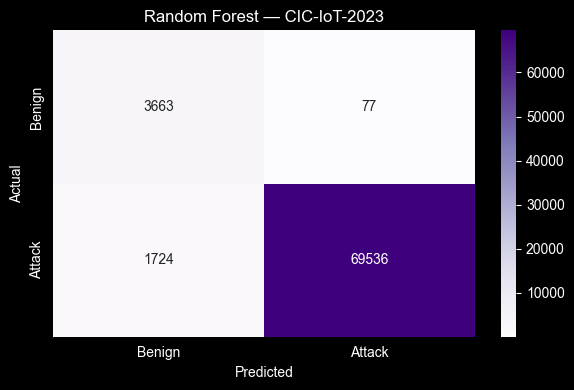

True Negatives:  3663
False Positives: 77
False Negatives: 1724
True Positives:  69536

Model saved.


In [2]:
# ── Train Random Forest ───────────────────────────────────────────────────
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Done.")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return {
        'f1': f1_score(y, y_pred),
        'auc_roc': roc_auc_score(y, y_prob),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'accuracy': accuracy_score(y, y_pred)
    }

val_metrics  = evaluate(rf, X_val,  y_val,  "Validation")
test_metrics = evaluate(rf, X_test, y_test, "Test")

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_test = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Random Forest — CIC-IoT-2023', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_rf_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

joblib.dump(rf, os.path.join(MODELS, "ciciot2023_random_forest.pkl"))
print("\nModel saved.")